# Assignment 05: Borůvka v. Kruskal


## “I Wrote the Code. You Measure It.”

You are given a fully working `MST` class (below) that computes a **minimum spanning tree** from an **adjacency matrix** using **two different techniques**:

- `boruvka()` — a barebones implementation that runs in about $\mathcal O(n^4)$.
- `kruskal()` — an implementation that runs in about $\mathcal O(n^2)$.

Your job is to **measure and compare their performance**. You should also study the implementation of Kruskal's technique and understand the _find-union_ methods work.


---

### Codebase


In [1]:
# 2345678901234567890123456789012345678901234567890123456789012345678901234567890

from copy import deepcopy


class MST:
    """A class with the methods necessary to produce a MST from the adjacency
    matrix of a weighted undirected graph. The class implements two techniques.
    First a barebone Boruvka method that runs in about $O(n^4)$ and next
    Kruska's technique that runs in about $O(n^2)$.
    """

    def __init__(self, G: list[list[int]]):
        """Initializes the MST object with the input graph G. Users are0
        expected to provide a symmetric square matrix with the diagonal
        values set to whatever semantic for no edge; this can be 0 or
        float('inf') which are the usual values; as long as the diagonal
        values are the same we're fine. Those values, found elsewere in
        the matrix will be viewed as no edge signals."""
        # Validate that the input graph is a non-empty square matrix
        if len(G) == 0 or len(G) != len(G[0]):
            raise ValueError("Input graph must be a non-empty square matrix")
        # Validate that the input graph is symmetric
        for i in range(len(G)):
            for j in range(len(G)):
                if G[i][j] != G[j][i]:
                    raise ValueError("Input graph must be undirected (symmetric)")
        # Validate that the input graph has no self-loops
        for i in range(len(G)):
            if G[i][i] != G[0][0]:
                raise ValueError("Input graph must have no self-loops")

        # Local copy of the input graph's adjacency matrix, so that we don't
        # accidentally modify the input graph. Also this local copy is
        # accessible to all methods of this class.
        self.G: list[list[int]] = deepcopy(G)
        # Shorthand notation for number of vertices, so that we don'try have to
        # keep writing len(self.G) all the time.
        self.n: int = len(self.G)
        # Shorthand of no-edge sentinel from input graph. Typicall we expect a 0
        # or an infinity as the no-edge sentinel, but we don't assume anything
        # here. We just take whatever is in G[0][0] as the no-edge sentinel.
        self.no_edge = G[0][0]
        # Adjacency matrix for MST. Initially it has no edges. This will be
        # populated as the algorithm progresses and will be the output
        # of the algorithm.
        self.T: list[list[int]] = [
            [self.no_edge for i in range(self.n)] for j in range(self.n)
        ]

        # Disjoint set data structures used by Kruskal. They live here because
        # we want them accessible to the private helper methods below.
        self._parent: list[int] = [i for i in range(self.n)]
        self._rank: list[int] = [0 for _ in range(self.n)]

    def _reachabilty(self, starting: int, graph: list[list[int]]) -> list[int]:
        """Determines the vertices of the input graph reachable from the
        starting vertex."""
        # List of reachable vertices
        reach: list[int] = []
        # List of vertices to explore next, primed with the starting vertex
        visit_next: list[int] = [starting]
        # Process every vertex in the visit_next list until it's empty.
        while len(visit_next) > 0:
            # Take a vertex out of the visit_next list. This can be the first
            # vertex in the list (operating it as a queue), the last vertex
            # (operating it as a stack), or any vertex with damn well please
            # (operating it as we like). All things being equal, stack is fine.
            vertex: int = visit_next.pop()
            if vertex not in reach:
                # Add this vertex to the reachable list
                reach.append(vertex)
                # Plan to visit this vertex's neighbors next
                for neighbor in range(self.n):
                    if graph[neighbor][vertex] != self.no_edge:
                        visit_next.append(neighbor)
        return reach  # Done!

    def _count_and_label(self):
        """Counts the components of the candidate MST (self.T) and labels its
        vertices with the component they belong to. For every vertex in the graph,
        track its component. The component label is the count value for each component
        when it was discovered. For example, if there are 3 components in the graph,
        the vertices in the first component will be labeled 1, those in the second
        component will be labeled 2, and those in the third component will be labeled 3.
        """
        # Count of components in the candidate MST
        count_of_components: int = 0
        # The component label for each vertex. Initialized to -1, meaning
        # that no vertex has been labeled yet.
        component_label: list[int] = [-1] * self.n
        # Remember the vertices we've seen so far. This is to avoid
        # double counting components.
        visited: list[int] = []
        # Process every vertex. If we haven't seen it before, it means
        # we've just found a new component.
        for vertex in range(self.n):
            if vertex not in visited:
                # We just found a new component, update the count. This count value
                # becomes the label for all vertices in this component.
                count_of_components += 1
                # Find everything we can reach from this vertex, because they'll be
                # in the same component
                reachable_from_vertex = self._reachabilty(vertex, self.T)
                # Add these reachable vertices to those visited, because
                # they are all in the same component and we don't want to
                # process them in the future.
                visited.extend(reachable_from_vertex)
                # The current component count becomes the label of all
                # these vertices
                for v in reachable_from_vertex:
                    component_label[v] = count_of_components
        return count_of_components, component_label  # Done

    # ------------------------------------------------------------------
    # Disjoint set operations for Kruskal. No imports. No nonsense.
    # ------------------------------------------------------------------

    def _ds_reset(self) -> None:
        """Resets the disjoint set structure so that every vertex is alone
        in its own little component, with zero baggage from previous runs."""
        self._parent = [i for i in range(self.n)]
        self._rank = [0 for _ in range(self.n)]

    def _ds_find(self, x: int) -> int:
        """Finds the representative of the set that contains x. We also do
        path compression, because we like our trees short and our finds fast."""
        while self._parent[x] != x:
            # Point x directly to its grandparent. This flattens the structure
            # over time and makes future finds cheaper.
            self._parent[x] = self._parent[self._parent[x]]
            x = self._parent[x]
        return x  # Done

    def _ds_union(self, a: int, b: int) -> bool:
        """Unions the sets of a and b. Returns True if we actually merged two
        different sets. Returns False if a and b were already in the same set."""
        ra = self._ds_find(a)
        rb = self._ds_find(b)
        merged = False
        if ra != rb:
            # Union by rank: attach the smaller tree under the bigger tree.
            if self._rank[ra] < self._rank[rb]:
                self._parent[ra] = rb
            elif self._rank[ra] > self._rank[rb]:
                self._parent[rb] = ra
            else:
                self._parent[rb] = ra
                self._rank[ra] += 1
            merged = True
        return merged  # Done

    def _edge_list(self) -> list[list[int]]:
        """Extracts the list of edges from the input graph. For an undirected
        graph stored as an adjacency matrix, we only look above the diagonal
        (u < v) so that we don't double-count edges like amateurs."""
        edges: list[list[int]] = []
        for u in range(self.n):
            for v in range(u + 1, self.n):
                if self.G[u][v] != self.no_edge:
                    # Represent an edge as [u, v, w]. Boring, but effective.
                    edges.append([u, v, self.G[u][v]])
        return edges  # Done

    def _alt_edge_list(self):
        edges = []
        for u in range(self.n):
            for v in range(u + 1, self.n):
                if self.G[u][v] != self.no_edge:
                    edges.append([self.G[u][v], u, v])
        return edges

    def _sort_edges_by_weight(self, edges: list[list[int]]) -> list[list[int]]:
        """Sorts the edge list by weight, smallest first. This uses Python's
        built-in sort."""
        # The weight lives at index 2, because we said so in _edge_list().
        edges.sort(key=lambda e: e[2])
        return edges  # Done

    def _alt_sort_edges_by_weight(self, edges):
        return sorted(edges)

    def boruvka(self):
        """The algorithm itself!"""
        # Start with a fresh empty MST matrix. No stale edges from past adventures.
        self.T = [[self.no_edge for i in range(self.n)] for j in range(self.n)]
        # Initialize count of components in the candidate MST and also get the
        # labels for each vertex in it.
        count_of_components, component_label = self._count_and_label()
        while count_of_components > 1:
            # Initialize a list to hold the safe edges for the various components.
            # Here lies a YUGE! implementation question. How to represent a safe edge?
            safe_edge = [None] * (self.n + 1)
            # Find any two vertices u, v in different components. The loop examines
            # all pairs of vertices above the main diagonal of the adjacency matrix.
            # There is no reason to look below the main diagonal, because the graph is
            # undirected and the adjacency matrix is symmetric. Also there is no reason
            # to look at the main diagonal, because there are no self-loops in the graph.
            # So we look at all pairs (u,v) such that u < v. For every such pair,
            # if u and v are in different components, we consider edge (u,v) as
            # a candidate for the safe edge of the component of u and also for
            # the safe edge of the component of v.
            for u in range(self.n):
                for v in range(u + 1, self.n):
                    # Is there an edge between u and v in the input graph?
                    if self.G[u][v] != self.no_edge:
                        if component_label[u] != component_label[v]:
                            # Vertices u, v are in different components. Let's figure
                            # out the safe edge for the component of vertex u. We do
                            # things below in a verbose manner for clarity. We'll be
                            # more concise when we do the same for component of vertex v.
                            if safe_edge[component_label[u]] is None:
                                # There is no safe edge for this component yet, so let's
                                # assume that (u,v) is just it. And here is how to represent
                                # the safe edge of a component.
                                safe_edge[component_label[u]] = [u, v]
                            else:
                                # There is currently a safe edge for this vertex, but is
                                # it truly the safest? Let's find out. Is edge (u,v)
                                # safer than the current safe edge for this component?
                                current_component = component_label[u]
                                current_safe_edge = safe_edge[current_component]
                                a = current_safe_edge[0]  # safe edge vertex a
                                b = current_safe_edge[1]  # safe edge vertex b
                                # Look up input graph for weigh of edge (a,b)
                                current_weight = self.G[a][b]
                                # Which of two edges (a,b) and (u,v) is safer, ie,
                                # has the smallest weight?
                                if self.G[u][v] < current_weight:
                                    # If (u,v) is smaller than the existing safe
                                    # edge (a,b) make (u,v) the safe edge for the
                                    # current component.
                                    safe_edge[current_component] = [u, v]
                            # It's component v's turn now. We repeat the same
                            # logic as above, but for component of vertex v. The
                            # code is a bit less verbose this time.
                            if safe_edge[component_label[v]] is None:
                                safe_edge[component_label[v]] = [v, u]
                            else:
                                [a, b] = safe_edge[component_label[v]]
                                if self.G[v][u] < self.G[a][b]:
                                    safe_edge[component_label[v]] = [v, u]
            # Add all the safe edges to the candidate MST
            for edge in safe_edge:
                if edge is not None:
                    u = edge[0]
                    v = edge[1]
                    self.T[u][v] = self.G[u][v]
                    self.T[v][u] = self.G[v][u]
            # Recount the components and re-label the vertices
            count_of_components, component_label = self._count_and_label()
        return self.T  # Done!

    def kruskal(self):
        """Compute the MST using Kruskal's technique. The plan is simple:
        (1) list all edges, (2) sort them by weight, (3) add them in that order
        so long as they don't create a cycle. Disjoint sets do the cycle check.
        """
        # Start with a fresh empty MST matrix. No stale edges from past adventures.
        self.T = [[self.no_edge for i in range(self.n)] for j in range(self.n)]
        # Reset the disjoint set structure: everyone starts alone.
        self._ds_reset()

        # Step 1: Gather all edges from the input graph.
        edges = self._edge_list()
        # Step 2: Sort edges from smallest weight to largest weight.
        edges = self._sort_edges_by_weight(edges)

        # Step 3: Walk the edges in sorted order and take the safe ones.
        edges_added = 0
        i = 0
        while i < len(edges) and edges_added < self.n - 1:
            # Switch uvw/wvu assignemnts depending on use of _alt methods
            # above
            u, v, w = edges[i]
            # w,u,v=edges[i]
            # If u and v are in different components, then adding (u,v) is safe.
            if self._ds_union(u, v):
                self.T[u][v] = w
                self.T[v][u] = w
                edges_added += 1
            i += 1

        return self.T  # Done!

In [2]:
graph = [
    [_, _, _, 5, 1, _],
    [_, _, 20, 5, _, 10],
    [_, 20, _, 10, _, _],
    [5, 5, 10, _, _, 15],
    [1, _, _, _, _, 20],
    [_, 10, _, 15, 20, _],
]

test = MST(graph)
Tb = test.boruvka()
Tk = test.kruskal()
print(Tb)
print(Tk)

[['', '', '', 5, 1, ''], ['', '', '', 5, '', 10], ['', '', '', 10, '', ''], [5, 5, 10, '', '', ''], [1, '', '', '', '', ''], ['', 10, '', '', '', '']]
[['', '', '', 5, 1, ''], ['', '', '', 5, '', 10], ['', '', '', 10, '', ''], [5, 5, 10, '', '', ''], [1, '', '', '', '', ''], ['', 10, '', '', '', '']]


---

# Solution and Technical Notes

The code below is written at a level above what was expected for this assignemnt, in order to provide an illustrative example of measuring efficiency. For your solution you were expected to run code resembling the following outline.

$$
\begin{align*}
& \textbf{for}\ \text{graph size}\ n\ \text{in range}\ 2, 4, \ldots \\
& \qquad {\color{maroon}\text{measure}_\text{kruskal} \leftarrow 0}  \\
& \qquad {\color{blue}\text{measure}_\text{borůvka} \leftarrow 0}  \\
& \qquad\textbf{for}\ \text{trial in range}\ 1,2,3 \ldots,\ {\color{green}\text{number of trials}}  \\
& \qquad\qquad \text{create graph}\ G \\ 
& \qquad\qquad {\color{blue}t_\text{start} \leftarrow \text{current system time}} \\
& \qquad\qquad {\color{blue}\text{compute}\ G\text{'s}\ \text{minimum spanning tree using Borůvka}} \\
& \qquad\qquad {\color{blue}\text{measure}_\text{borůvka} \leftarrow\ \text{measure}_\text{borůvka}+ \text{current system time}-t_\text{start}} \\ 
& \qquad\qquad {\color{maroon}t_\text{start} \leftarrow \text{current system time}} \\
& \qquad\qquad {\color{maroon}\text{compute}\ G\text{'s}\ \text{minimum spanning tree using Kruskal}} \\
& \qquad\qquad {\color{maroon}\text{measure}_\text{kruskal} \leftarrow\ \text{measure}_\text{kruskal}+ \text{current system time}-t_\text{start}} \\ 
& \qquad\textbf{end for}  \\
& \qquad {\color{blue}\text{average time for Borůvka for size}\ n \leftarrow \text{measure}_\text{borůvka}/{\color{green}\text{number of trials}}}  \\
& \qquad {\color{maroon}\text{average time for Kruskal for size}\ n \leftarrow \text{measure}_\text{kruskal}/{\color{green}\text{number of trials}}} 
\end{align*}
$$

It is important to take multiple measurements of the time required for each technique -- that's what ${\color{green}\text{number of trials}}$ is about.

n=    1  boruvka=0.000005s  kruskal=0.000005s
n=    2  boruvka=0.000012s  kruskal=0.000006s
n=    4  boruvka=0.000019s  kruskal=0.000009s
n=    8  boruvka=0.000062s  kruskal=0.000021s
n=   16  boruvka=0.000183s  kruskal=0.000041s
n=   32  boruvka=0.000496s  kruskal=0.000107s
n=   64  boruvka=0.002269s  kruskal=0.000337s
n=  128  boruvka=0.008230s  kruskal=0.001339s
n=  256  boruvka=0.036400s  kruskal=0.005214s
n=  512  boruvka=0.092279s  kruskal=0.017116s
n= 1024  boruvka=0.542244s  kruskal=0.085560s


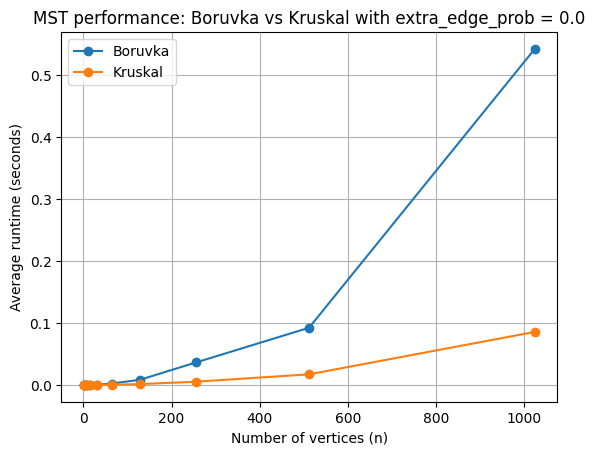

n=    1  boruvka=0.000003s  kruskal=0.000003s
n=    2  boruvka=0.000007s  kruskal=0.000004s
n=    4  boruvka=0.000012s  kruskal=0.000006s
n=    8  boruvka=0.000034s  kruskal=0.000012s
n=   16  boruvka=0.000105s  kruskal=0.000026s
n=   32  boruvka=0.000323s  kruskal=0.000075s
n=   64  boruvka=0.001206s  kruskal=0.000240s
n=  128  boruvka=0.004935s  kruskal=0.001363s
n=  256  boruvka=0.028977s  kruskal=0.007675s
n=  512  boruvka=0.117323s  kruskal=0.018033s
n= 1024  boruvka=0.541709s  kruskal=0.077717s


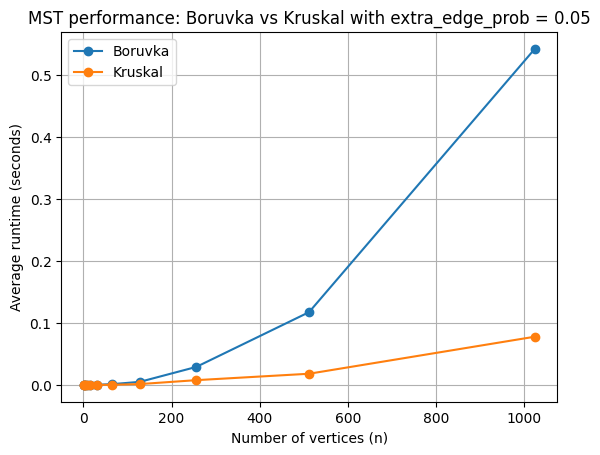

n=    1  boruvka=0.000004s  kruskal=0.000003s
n=    2  boruvka=0.000007s  kruskal=0.000004s
n=    4  boruvka=0.000012s  kruskal=0.000007s
n=    8  boruvka=0.000040s  kruskal=0.000012s
n=   16  boruvka=0.000081s  kruskal=0.000026s
n=   32  boruvka=0.000336s  kruskal=0.000090s
n=   64  boruvka=0.001218s  kruskal=0.000250s
n=  128  boruvka=0.006150s  kruskal=0.001475s
n=  256  boruvka=0.034697s  kruskal=0.006844s
n=  512  boruvka=0.113245s  kruskal=0.020252s
n= 1024  boruvka=0.507177s  kruskal=0.132374s


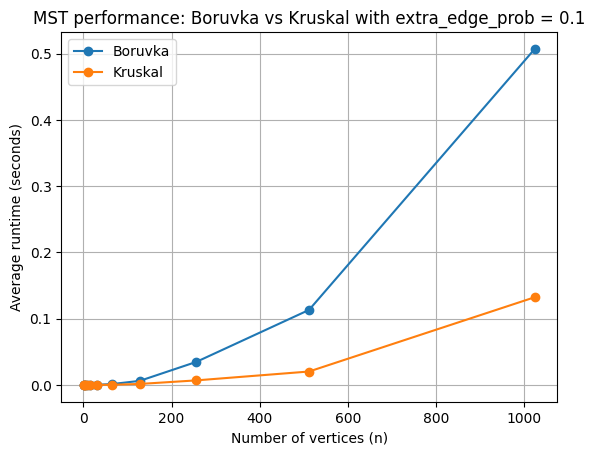

n=    1  boruvka=0.000003s  kruskal=0.000003s
n=    2  boruvka=0.000011s  kruskal=0.000006s
n=    4  boruvka=0.000012s  kruskal=0.000006s
n=    8  boruvka=0.000034s  kruskal=0.000013s
n=   16  boruvka=0.000123s  kruskal=0.000031s
n=   32  boruvka=0.000282s  kruskal=0.000101s
n=   64  boruvka=0.001396s  kruskal=0.000387s
n=  128  boruvka=0.006369s  kruskal=0.002290s
n=  256  boruvka=0.033419s  kruskal=0.009604s
n=  512  boruvka=0.116150s  kruskal=0.040189s
n= 1024  boruvka=0.509431s  kruskal=0.229733s


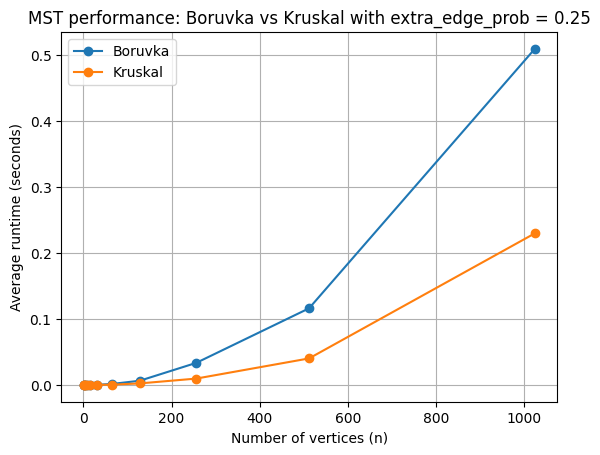

n=    1  boruvka=0.000003s  kruskal=0.000002s
n=    2  boruvka=0.000007s  kruskal=0.000004s
n=    4  boruvka=0.000012s  kruskal=0.000007s
n=    8  boruvka=0.000042s  kruskal=0.000013s
n=   16  boruvka=0.000096s  kruskal=0.000035s
n=   32  boruvka=0.000425s  kruskal=0.000118s
n=   64  boruvka=0.001963s  kruskal=0.000644s
n=  128  boruvka=0.007028s  kruskal=0.002702s
n=  256  boruvka=0.040764s  kruskal=0.018862s
n=  512  boruvka=0.138520s  kruskal=0.083783s
n= 1024  boruvka=0.597541s  kruskal=0.383974s


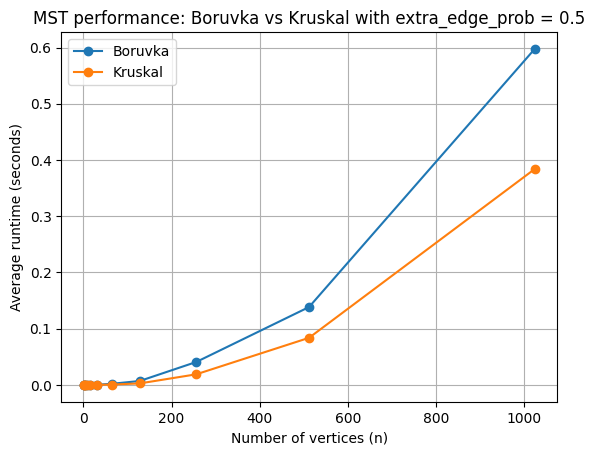

n=    1  boruvka=0.000004s  kruskal=0.000003s
n=    2  boruvka=0.000010s  kruskal=0.000005s
n=    4  boruvka=0.000018s  kruskal=0.000010s
n=    8  boruvka=0.000063s  kruskal=0.000023s
n=   16  boruvka=0.000186s  kruskal=0.000078s
n=   32  boruvka=0.000833s  kruskal=0.000423s
n=   64  boruvka=0.001778s  kruskal=0.001123s
n=  128  boruvka=0.013260s  kruskal=0.004345s
n=  256  boruvka=0.030046s  kruskal=0.021452s
n=  512  boruvka=0.140978s  kruskal=0.104591s
n= 1024  boruvka=0.532720s  kruskal=0.596897s


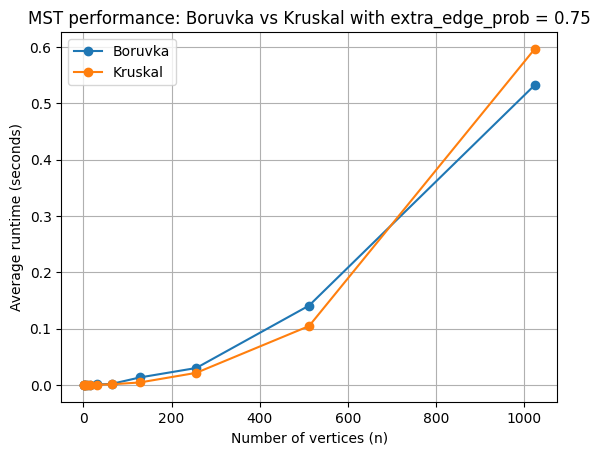

n=    1  boruvka=0.000004s  kruskal=0.000003s
n=    2  boruvka=0.000010s  kruskal=0.000006s
n=    4  boruvka=0.000013s  kruskal=0.000007s
n=    8  boruvka=0.000040s  kruskal=0.000016s
n=   16  boruvka=0.000130s  kruskal=0.000050s
n=   32  boruvka=0.000613s  kruskal=0.000254s
n=   64  boruvka=0.003290s  kruskal=0.001863s
n=  128  boruvka=0.007417s  kruskal=0.003402s
n=  256  boruvka=0.023458s  kruskal=0.023324s
n=  512  boruvka=0.127330s  kruskal=0.129704s
n= 1024  boruvka=0.570693s  kruskal=0.695965s


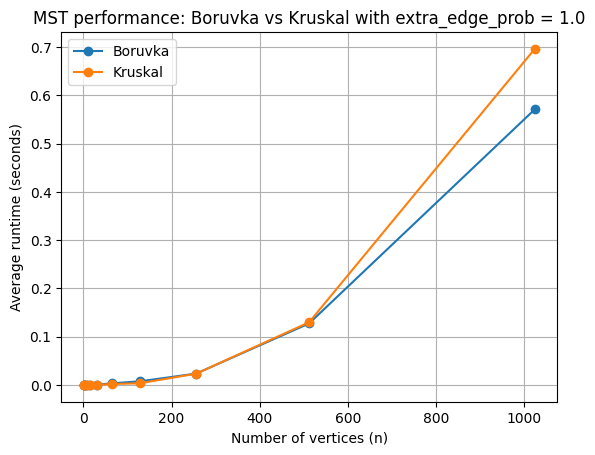

In [3]:
import random
import time
import matplotlib.pyplot as plt

MIN_EDGE_WEIGHT = 1
MAX_EDGE_WEIGHT = 30
EDGE_PROB = 0.25

# -----------------------------
# Graph generator (connected)
# -----------------------------
def make_connected_graph_matrix(
    n: int,
    extra_edge_prob: float = EDGE_PROB,
    w_min: int = MIN_EDGE_WEIGHT,
    w_max: int = MAX_EDGE_WEIGHT,
    no_edge: int = 0,
    seed: int | None = None,
) -> list[list[int]]:
    """
    Create an undirected, connected, weighted graph as a symmetric adjacency matrix.
    The graph has n vertices, edge weights between w_min and w_max, and no edge is
    represented by no_edge. The graph is connected, meaning there is a path between
    any two vertices.

    Strategy:
      1) Build a random spanning tree (guarantees connectivity).
      2) Add extra random edges with probability extra_edge_prob.

    no_edge is used on the diagonal and for missing edges elsewhere.
    """
    rng = random.Random(seed)

    G = [[no_edge for _ in range(n)] for _ in range(n)]
    # Diagonal already set to no_edge; this matches MST's "no self-loops" rule.

    # Random spanning tree: connect each new vertex i to a random earlier vertex
    for i in range(1, n):
        j = rng.randrange(0, i)
        w = rng.randint(w_min, w_max)
        G[i][j] = w
        G[j][i] = w

    # Add extra edges with probability extra_edge_prob
    for u in range(n):
        for v in range(u + 1, n):
            # If there is no edge between u and v, "flip a coin" to decide 
            # whether to add one
            if G[u][v] == no_edge and rng.random() < extra_edge_prob:
                # Select a random weight for this new edge and add it to the graph
                w = rng.randint(w_min, w_max)
                G[u][v] = w
                G[v][u] = w
    return G


# ----------------------------
# Orchestration of benchmark
# ----------------------------
def benchmark(
    sizes: list[int],
    number_of_trials: int = 3,
    extra_edge_prob: float = EDGE_PROB,
    w_min: int = MIN_EDGE_WEIGHT,
    w_max: int = MAX_EDGE_WEIGHT,
    seed: int = 0,
) -> tuple[list[float], list[float]]:
    """
    For each n in sizes:
      - generate one graph (fixed per n)
      - run 'boruvka' number_of_trials times and average
      - run 'kruskal' number_of_trials times and average
    """
    bor_times = []
    kru_times = []

    for n in sizes:
        G = make_connected_graph_matrix(
            n,
            extra_edge_prob=extra_edge_prob,
            w_min=w_min,
            w_max=w_max,
            no_edge=0,
            seed=seed + n,  # deterministic-but-different per size
        )

        # Average timings
        b = 0.0  # measure of boruvka time
        k = 0.0  # measure of kruskal time
        # instantiate once and reuse for all trials, since the methods don't modify G
        m = MST(G) 
        for _ in range(number_of_trials):
            start_time = time.perf_counter()
            t = m.boruvka()
            end_time = time.perf_counter()
            b += end_time - start_time
            start_time = time.perf_counter()
            t = m.kruskal()
            end_time = time.perf_counter()
            k += end_time - start_time
        bor_times.append(b / number_of_trials)
        kru_times.append(k / number_of_trials)

        print(f"n={n:5d}  boruvka={bor_times[-1]:.6f}s  kruskal={kru_times[-1]:.6f}s")

    return bor_times, kru_times


# -----------------------------
# Run benchmark + plot
# -----------------------------
# Boruvka is much slower in this implementation, so keep sizes modest.
sizes = [2**n for n in range(11)]

# density knob: raise for denser graphs
for extra_edge_prob in [0.0, 0.05, 0.1, 0.25, 0.50, 0.75, 1.0]:

    boruvka_avg, kruskal_avg = benchmark(
        sizes=sizes,
        number_of_trials=3,
        extra_edge_prob=extra_edge_prob,
        w_min=MIN_EDGE_WEIGHT,
        w_max=MAX_EDGE_WEIGHT,
        seed=12345,
    )

    plt.figure()
    plt.plot(sizes, boruvka_avg, marker="o", label="Boruvka")
    plt.plot(sizes, kruskal_avg, marker="o", label="Kruskal")
    plt.xlabel("Number of vertices (n)")
    plt.ylabel("Average runtime (seconds)")
    plt.title(f"MST performance: Boruvka vs Kruskal with {extra_edge_prob = }")
    plt.legend()
    plt.grid(True)
    plt.show()